**Data analysis topic background**

Question & answer results obtained from Internet search

Q1: Did the Singapore resale flat prices increased over these recent years? Why?

A1: Yes, Singapore HDB resale flat prices increased significantly over recent years, particularly since the second quarter of 2020, though the pace of growth has started to moderate in late 2024 and 2025. The price increases were driven by a combination of various demand and supply-side factors including
a) Supply Shortages due to COVID-19
b) Availibility of Government housing Grants which supported demand by increasing the purchasing power of first-time buyers. 

Q2: Did the increase in Singapore HDB resale prices for these recent years cause rents to increase?

A2: Yes, the surge in HDB resale prices in recent years has significantly contributed to rising rental costs in Singapore, pushing many towards renting as higher purchase prices and delayed BTO supply increase demand, while cooling measures also pushed some ex-private owners into the rental market, creating a ripple effect that drives up both HDB and private property rental rates.

**Objective of notebook**

a. Using relevant data.gov.sg HDB datasets, investigate, evaluate and conclude if the claims in answers (A1, A2) explanations are correct from period 2018 to 2023. 

b. Therefore, this notebook will perform exploratory data analysis (EDA) to evaluate these objectives:
1) Which public housing type contributes most to the resale transactions and thus most significantly to overall resale price market 
2) Focusing on public housing type identified in 1), analyze the resale prices for four representative estates in north (woodlands), central (ang mo kio), east (tampines), west (jurong east)
3) Investigate the relationship between resale prices and median rent for focused public housing type in objective 1)
4) Investigate if the claimed causes of resale price increase situation is correct

This notebook would be split into four part analysis sections - section 1, 2, 3, 4. Each section addressing respective objective #.

**Instructions to user**
1. Click "Run > Run all cells" menu option to run all cells from first cell to last cell.
2. Generated output results analysis plots would be saved in jpg format in project directory under "figure" folder for reference and subsequent usage.

---------------------------
**Setup section**

Perform variable declarations and other necessary operations to implement setup procedures before the running the python routines in the main sections that build upon it.

In [1]:
# pre-defined for whole notebook, dictionary of consolidated variables mapping to actual file path for raw dataset files
dataset_files = { 
                  "data_set_1_1": "data/1/NumberofResaleApplicationsRegisteredbyFlatType.csv", 
                  "data_set_1_2": "data/1/ResaleTransactionsbyFlatTypebasedonregisteredcases.csv",
                  "data_set_2_1": "data/2/HDBResalePriceIndex1Q2009100Quarterly.csv",
                  "data_set_2_2": "data/2/MedianResalePricesforRegisteredApplicationsbyTownandFlatType.csv",
                  "data_set_2_3": "data/2/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv",
                  "data_set_3_1": "data/3/MedianRentByTownAndFlatType.csv",
                  "data_set_4_1": "data/4/CompletionStatusofHDBResidentialDevelopments.csv",
                  "data_set_4_2": "data/4/CPFHousingGrantsAwardedbyType.csv"
                }
# pre-defined figure file paths for saving generated plots to specified directory for backup 
figure_files =  { 
                  "fig_1_1": "figure/fig_1_1.jpg",
                  "fig_1_2": "figure/fig_1_2.jpg",
                  "fig_2_1": "figure/fig_2_1.jpg",
                  "fig_2_2": "figure/fig_2_2.jpg",
                  "fig_2_3": "figure/fig_2_3.jpg",
                  "fig_3_1": "figure/fig_3_1.jpg",
                  "fig_4_1": "figure/fig_4_1.jpg",
                  "fig_4_2": "figure/fig_4_2.jpg"
                }

---------------------------
**Section 1**

Implement data retrival, manipulation, transformation, presentation operations to address objective 1) Which public housing type contributes most to the resale transactions and thus most significantly to overall resale price market 

**section 1.1) data_set_1_1**

data.gov.sg dataset: Number of Resale Applications Registered by Flat Type

URL: https://data.gov.sg/datasets?query=hdb&resultId=d_02aa4bb51bc674f3a2d0b9bb6911d934&page=6 

filename: NumberofResaleApplicationsRegisteredbyFlatType.csv  

output result analysis plot filename: fig_1_1.jpg

output plot type: pie chart

**section 1.2) data_set_1_2**

data.gov.sg dataset: Resale Transactions by Flat Type (based on registered cases)

URL: https://data.gov.sg/datasets?query=hdb&resultId=d_27af98d638a80103319cb7499c220fe6&page=6

filename: ResaleTransactionsbyFlatTypebasedonregisteredcases.csv  

output result analysis plot filename: fig_1_2.jpg

output plot type: horizontal bar chart

**Section 1.1**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2018-2023

[3] Array mathematics
- Perform summation of resale applications for whole year for each flat type

[4] Transformation to new dataset
- Generate new row of summed statistics with year and flat type and append to new dataset array

[5] New dataset extraction operations
- Extract into correct x-axis and y-axis data format to input to matplotlib plot, minor data manipulations might be done

[6] Data presentation 
- Perform various plot adjustments to present statistics according to suitable display partitioning to answer section objective

In [2]:
import numpy as np

def extract_year_rows(year, data):
    print(f'Extracting rows for year: {year}')
    mask_y = np.char.startswith(data['quarter'], year)
    data_of_year = data[mask_y]
    return data_of_year

def extract_type_rows(type, data):
    print(f'Extracting rows for type: {type}')
    mask_t = (data['flat_type'] == type)
    data_of_type = data[mask_t]
    return data_of_type

def generate_summed_row(year, type, type_sum):
    print(f'Generate summed row for year: {year}, type: {type}')
    new_dtype = [('year','U10'), ('flat_type','U15'), ('no_of_resale_applications','i8')]
    data_summed = np.empty((1,), dtype=new_dtype)
    data_summed['year'] = year
    data_summed['flat_type'] = type
    data_summed['no_of_resale_applications'] = type_sum
    return data_summed

def init_summed_row():
    new_dtype = [('year','U10'), ('flat_type','U15'), ('no_of_resale_applications','i8')]
    empty_frame = np.empty((0,), dtype=new_dtype)
    return empty_frame

debug_on = False
filename = dataset_files["data_set_1_1"]
dtype1=[('quarter','U10'),  ('flat_type','U15'),('no_of_resale_applications','i8')]
data = np.genfromtxt(filename, skip_header=1, dtype=dtype1 , delimiter=",", missing_values=['na','-'], filling_values=0)
print(f"Checking data set shape: {data.shape}")
print("Peeking at dataset first 5 rows:")
print(data[:5])

ndarr_final = init_summed_row();

year_list = ['2018', '2019', '2020', '2021', '2022', '2023']
# filtering by year and flat type, calculating sum and constructing new dataset for plot of fig 1.1
for year in year_list:
    print(f"----- {year} -----")
    data_of_year = extract_year_rows(year, data)
    if debug_on: print(data_of_year)

    type_list = ['1-room', '2-room', '3-room', '4-room', '5-room', 'Executive']

    for flat_type in type_list:
        print(f"----- {flat_type} -----")
        data_of_type = extract_type_rows(flat_type, data_of_year)
        if debug_on: print(data_of_type)
        type_sum = np.sum(data_of_type['no_of_resale_applications'])
        summed_row = generate_summed_row(year, flat_type, type_sum)
        if debug_on: print(summed_row)
        ndarr_final = np.append(ndarr_final, summed_row)
        #if debug_on: print(ndarr_final)

dataset_fig_1_1 = ndarr_final

print("-----")
print("Final dataset generated to use for fig 1.1:")
print(dataset_fig_1_1)

Checking data set shape: (444,)
Peeking at dataset first 5 rows:
[('2007-Q1', '1-room',    5) ('2007-Q1', '2-room',   67)
 ('2007-Q1', '3-room', 1908) ('2007-Q1', '4-room', 2365)
 ('2007-Q1', '5-room', 1402)]
----- 2018 -----
Extracting rows for year: 2018
----- 1-room -----
Extracting rows for type: 1-room
Generate summed row for year: 2018, type: 1-room
----- 2-room -----
Extracting rows for type: 2-room
Generate summed row for year: 2018, type: 2-room
----- 3-room -----
Extracting rows for type: 3-room
Generate summed row for year: 2018, type: 3-room
----- 4-room -----
Extracting rows for type: 4-room
Generate summed row for year: 2018, type: 4-room
----- 5-room -----
Extracting rows for type: 5-room
Generate summed row for year: 2018, type: 5-room
----- Executive -----
Extracting rows for type: Executive
Generate summed row for year: 2018, type: Executive
----- 2019 -----
Extracting rows for year: 2019
----- 1-room -----
Extracting rows for type: 1-room
Generate summed row for year

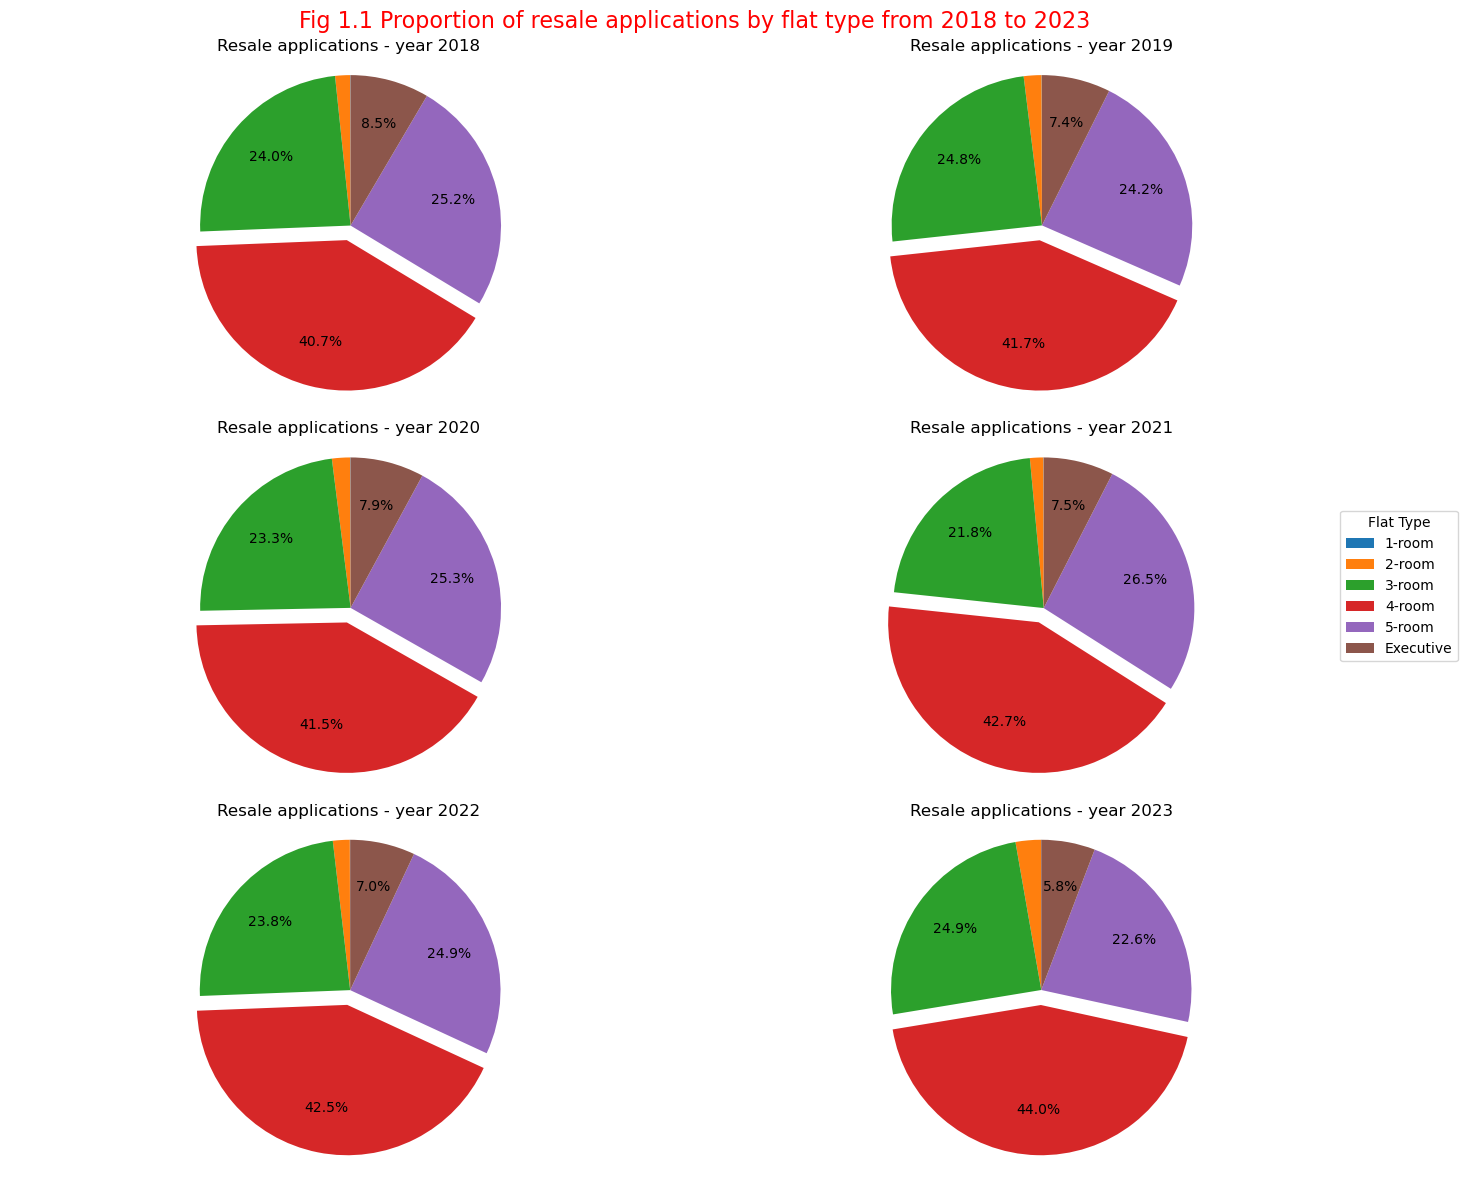

In [3]:
import matplotlib.pyplot as plt

def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 3 else ''  # hide < 3%

debug_on = False
start_year = 2018
num_of_years = 6
year_subset_ls = []

for inc in range(num_of_years):
    current_year = str(start_year + inc)
    mask_year = (dataset_fig_1_1['year'] == current_year)
    year_subset = dataset_fig_1_1[mask_year]
    year_subset_ls.append(year_subset)

year_2018 = year_subset_ls[0]
year_2019 = year_subset_ls[1]

if debug_on:
    print(year_2018)
    print(year_2019)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
plot_title = f'Fig 1.1 Proportion of resale applications by flat type from {start_year} to {start_year + num_of_years - 1}'
fig.suptitle(plot_title, fontsize=16, fontweight='normal', color='red')

ls_index = 0
for row in range(3):
    ls_index = row*2
    year_subset_left = year_subset_ls[ls_index]
    year_subset_right = year_subset_ls[ls_index + 1]
    sizes_left_pie = year_subset_left['no_of_resale_applications'].tolist()
    sizes_right_pie = year_subset_right['no_of_resale_applications'].tolist()

    year_left = start_year + ls_index

    labels = ['1-room', '2-room', '3-room', '4-room', '5-room', 'Executive']
    explode = (0, 0, 0, 0.1, 0, 0)
    # Left column
    wedges, _, _ = axes[row, 0].pie(
        sizes_left_pie,
        explode=explode,
        autopct=autopct_format,
        startangle=90,
        pctdistance=0.7,
        textprops={'fontsize': 10}
    )
    axes[row, 0].axis('equal')
    axes[row, 0].set_title(f"Resale applications - year {year_left}")
    # Right column
    wedges, _, _ = axes[row, 1].pie(
        sizes_right_pie,
        explode=explode,
        autopct=autopct_format,
        startangle=90,
        pctdistance=0.7,
        textprops={'fontsize': 10}
    )
    axes[row, 1].axis('equal')
    axes[row, 1].set_title(f"Resale applications - year {year_left + 1}")   

fig.legend(wedges, labels, title="Flat Type", loc="center right", bbox_to_anchor=(1.05, 0.5))

plt.tight_layout()
plt.savefig(figure_files["fig_1_1"], dpi=300, bbox_inches='tight')
plt.show()

**Section 1.2**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2018-2023

[3] Array mathematics
- Perform summation of resale applications for whole year for each flat type

[4] Transformation to new dataset
- Generate new row of summed statistics with year and flat type and append to new dataset array

[5] New dataset extraction operations
- Extract into correct x-axis and y-axis data format to input to matplotlib plot, minor data manipulations might be done

[6] Data presentation 
- Perform various plot adjustments to present statistics according to suitable display partitioning to answer section objective

In [4]:
import numpy as np

def extract_year_rows(year, data):
    print(f'Extracting rows for year: {year}')
    mask_y = np.char.startswith(data['quarter'], year)
    data_of_year = data[mask_y]
    return data_of_year

def extract_type_rows(type, data):
    print(f'Extracting rows for type: {type}')
    mask_t = (data['flat_type'] == type)
    data_of_type = data[mask_t]
    return data_of_type

def generate_summed_row(year, type, type_sum):
    print(f'Generate summed row for year: {year}, type: {type}')
    new_dtype = [('year','U10'), ('flat_type','U15'), ('no_of_resale_applications','i8')]
    data_summed = np.empty((1,), dtype=new_dtype)
    data_summed['year'] = year
    data_summed['flat_type'] = type
    data_summed['no_of_resale_applications'] = type_sum
    return data_summed

def init_summed_row():
    new_dtype = [('year','U10'), ('flat_type','U15'), ('no_of_resale_applications','i8')]
    empty_frame = np.empty((0,), dtype=new_dtype)
    return empty_frame

data = ndarr_final = data_of_year = data_of_type = summed_row = None
debug_on = False

filename = dataset_files["data_set_1_2"]
print(f"Extracting data set 1_2 from file: {filename}")
dtype1=[('quarter','U10'),  ('flat_type','U15'),('no_of_resale_applications','i8')]

data = np.genfromtxt(filename, skip_header=1, dtype=dtype1 , delimiter=",", missing_values=['na','-'], filling_values=0)

print(f"Checking data set shape: {data.shape}")
print("Peeking at dataset first and last 6 rows:")
print(data[:6])
print(data[-6:])

ndarr_final = init_summed_row();

year_list = ['2018', '2019', '2020', '2021', '2022', '2023']
 # filtering by year and flat type, calculating sum and constructing new dataset for plot of fig 1.2
for year in year_list:
    print(f"----- {year} -----")
    data_of_year = extract_year_rows(year, data)
    if(debug_on): print(data_of_year)    

    type_list = ['1-room', '2-room', '3-room', '4-room', '5-room', 'Executive']

    for flat_type in type_list:
        print(f"----- {flat_type} -----")
        data_of_type = extract_type_rows(flat_type, data_of_year)
        if(debug_on): print(data_of_type)
        type_sum = np.sum(data_of_type['no_of_resale_applications'])
        summed_row = generate_summed_row(year, flat_type, type_sum)
        if(debug_on): print(summed_row)
        ndarr_final = np.append(ndarr_final, summed_row)
        if(debug_on): print(ndarr_final)

dataset_fig_1_2 = ndarr_final

print("-----")
print("Final dataset generated to use for fig 1.2:")
print(dataset_fig_1_2)

Extracting data set 1_2 from file: data/1/ResaleTransactionsbyFlatTypebasedonregisteredcases.csv
Checking data set shape: (438,)
Peeking at dataset first and last 6 rows:
[('2007-Q1', '1-room',    5) ('2007-Q1', '2-room',   67)
 ('2007-Q1', '3-room', 1908) ('2007-Q1', '4-room', 2365)
 ('2007-Q1', '5-room', 1402) ('2007-Q1', 'Executive',  511)]
[('2025-Q1', '1-room',    1) ('2025-Q1', '2-room',  220)
 ('2025-Q1', '3-room', 1687) ('2025-Q1', '4-room', 2825)
 ('2025-Q1', '5-room', 1482) ('2025-Q1', 'Executive',  375)]
----- 2018 -----
Extracting rows for year: 2018
----- 1-room -----
Extracting rows for type: 1-room
Generate summed row for year: 2018, type: 1-room
----- 2-room -----
Extracting rows for type: 2-room
Generate summed row for year: 2018, type: 2-room
----- 3-room -----
Extracting rows for type: 3-room
Generate summed row for year: 2018, type: 3-room
----- 4-room -----
Extracting rows for type: 4-room
Generate summed row for year: 2018, type: 4-room
----- 5-room -----
Extracti

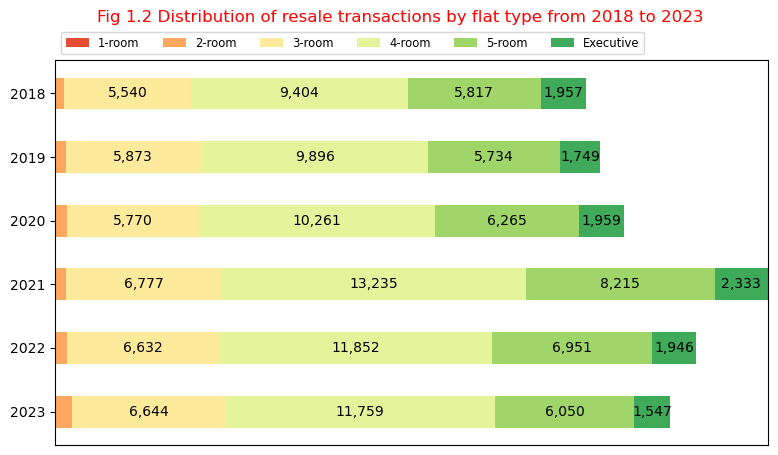

In [5]:
import matplotlib.pyplot as plt
import numpy as np

start_year = 2018
num_of_years = 6
year_subset_ls = []
# constructing the plot data in correct format from dataset_fig_1_2
for inc in range(num_of_years):
    current_year = str(start_year + inc)
    mask_year = (dataset_fig_1_2['year'] == current_year)
    year_subset = dataset_fig_1_2[mask_year]
    year_subset_ls.append(year_subset)

category_names = ['1-room', '2-room', '3-room', '4-room', '5-room', 'Executive']
results = {
    '2018': year_subset_ls[0]['no_of_resale_applications'].tolist(),
    '2019': year_subset_ls[1]['no_of_resale_applications'].tolist(),
    '2020': year_subset_ls[2]['no_of_resale_applications'].tolist(),
    '2021': year_subset_ls[3]['no_of_resale_applications'].tolist(),
    '2022': year_subset_ls[4]['no_of_resale_applications'].tolist(),
    '2023': year_subset_ls[5]['no_of_resale_applications'].tolist()
}

labels = list(results.keys())
data = np.array(list(results.values()))
data_cum = data.cumsum(axis=1)
category_colors = plt.colormaps['RdYlGn'](np.linspace(0.15, 0.85, data.shape[1]))

fig, axes = plt.subplots(figsize=(9.2, 5))
plot_title = f'Fig 1.2 Distribution of resale transactions by flat type from {start_year} to {start_year + num_of_years - 1}'
fig.suptitle(t=plot_title, fontsize=12, fontweight='normal', color='red')

axes.invert_yaxis()
axes.xaxis.set_visible(False)
axes.set_xlim(0, np.sum(data, axis=1).max())

for i, (colname, color) in enumerate(zip(category_names, category_colors)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = axes.barh(labels, widths, left=starts, height=0.5, label=colname, color=color)
    # if the value is too small, text annotation is dropped
    labels_conditional = [f'{int(w):,}' if w >= 1000 else '' for w in widths]

    r, g, b, _ = color
    axes.bar_label(rects, labels=labels_conditional, label_type='center', color='black')

axes.legend(ncols=len(category_names), bbox_to_anchor=(0, 1), loc='lower left', fontsize='small')
plt.savefig(figure_files["fig_1_2"], dpi=300, bbox_inches='tight')
plt.show()


**Objective addressed for section 1**

From section 1.1 and 1.2, the plot results in pie chart figure 1.1 and horizontal bar chart figure 1.2 indicates that 4-room flat type is the largest housing type 
that contributes most to the resale transactions and thus most significantly to overall resale price market. Therefore, subsequent sections would focus and narrow onto 4-room flat type only for data analysis. 

---------------------------
**Section 2**

Implement data retrival, manipulation, transformation, presentation operations to address objective 2) Focusing on 4-room flat type identified in section 1), analyze the resale prices for four representative estates in north (woodlands), central (ang mo kio), east (tampines), west (jurong east)

**section 2.1) data_set_2_1**

data.gov.sg dataset: HDB Resale Price Index (1Q2009 = 100), Quarterly

URL: https://data.gov.sg/datasets?query=hdb&resultId=d_14f63e595975691e7c24a27ae4c07c79&page=3

filename: HDBResalePriceIndex1Q2009100Quarterly.csv

output result analysis plot filename: fig_2_1.jpg

output plot type: line chart

**section 2.2) data_set_2_2**

data.gov.sg dataset: Median Resale Prices for Registered Applications by Town and Flat Type

URL: https://data.gov.sg/datasets?query=hdb&resultId=d_b51323a474ba789fb4cc3db58a3116d4&page=6

filename: MedianResalePricesforRegisteredApplicationsbyTownandFlatType.csv

output result analysis plot filename: fig_2_2.jpg

output plot type: heat map

**section 2.3) data_set_2_3**

data.gov.sg dataset: Resale flat prices based on registration date from Jan-2017 onwards

URL: https://data.gov.sg/datasets?query=hdb&resultId=d_8b84c4ee58e3cfc0ece0d773c8ca6abc&page=6

filename: ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv

output result analysis plot filename: fig_2_3.jpg

output plot type: box plot

**Section 2.1**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2018-2023

[3] Array mathematics
- Perform mean of resale price index for whole year

[4] Transformation to new dataset
- Generate new row of mean statistics with year and append to new dataset array

[5] New dataset extraction operations
- Extract into correct x-axis and y-axis data format to input to matplotlib plot, minor data manipulations might be done

[6] Data presentation 
- Perform various plot adjustments to present statistics according to suitable display partitioning to answer section objective

In [6]:
import numpy as np

def extract_year_rows(year, data):
    print(f'Extracting rows for year: {year}')
    mask_y = np.char.startswith(data['quarter'], year)
    data_of_year = data[mask_y]
    return data_of_year

def init_mean_row_ds21():
    new_dtype = [('year','U10'),('mean_index','f8')]
    empty_frame = np.empty((0,), dtype=new_dtype)
    return empty_frame

def generate_mean_row_ds21(year, indices_mean):
    print(f'Generate mean row for year: {year}')
    new_dtype = [('year','U10'),('mean_index','f8')]
    data_averaged = np.empty((1,), dtype=new_dtype)
    data_averaged['year'] = year
    data_averaged['mean_index'] = indices_mean
    return data_averaged

data = ndarr_final = data_of_year = None
debug_on = True

filename = dataset_files["data_set_2_1"]
print(f"Extracting data set 2_1 from file: {filename}")
dtype_ds_2_1=[('quarter','U10'),('index','f8')]

data = np.genfromtxt(filename, skip_header=1, dtype=dtype_ds_2_1 , delimiter=",", missing_values=['na','-'], filling_values=0)
print(f"Checking data set shape: {data.shape}")
print("Peeking at dataset first and last 4 rows:")
print(data[:4])
print(data[-4:])

ndarr_final = init_mean_row_ds21();

year_list = ['2018', '2019', '2020', '2021', '2022', '2023']
 # filtering by year, calculating mean and constructing new dataset for plot of fig 2.1
for year in year_list:
    print(f"----- {year} -----")
    data_of_year = extract_year_rows(year, data) 
    if(debug_on): print(data_of_year)
    year_indices_mean = np.mean(data_of_year['index'])
    year_indices_mean = round(year_indices_mean, 2)
    if(debug_on): print(f"year: {year}, mean_index: {year_indices_mean}")
    mean_row = generate_mean_row_ds21(year, year_indices_mean)
    if(debug_on): print(mean_row)
    ndarr_final = np.append(ndarr_final, mean_row)
    if(debug_on): print(ndarr_final)

dataset_fig_2_1 = ndarr_final
print("-----")
print("Final dataset generated to use for fig 2.1:")
print(dataset_fig_2_1)

Extracting data set 2_1 from file: data/2/HDBResalePriceIndex1Q2009100Quarterly.csv
Checking data set shape: (143,)
Peeking at dataset first and last 4 rows:
[('1990-Q1', 24.3) ('1990-Q2', 24.4) ('1990-Q3', 25. ) ('1990-Q4', 24.7)]
[('2024-Q4', 197.9) ('2025-Q1', 201. ) ('2025-Q2', 202.9)
 ('2025-Q3', 203.7)]
----- 2018 -----
Extracting rows for year: 2018
[('2018-Q1', 131.6) ('2018-Q2', 131.7) ('2018-Q3', 131.6)
 ('2018-Q4', 131.4)]
year: 2018, mean_index: 131.57
Generate mean row for year: 2018
[('2018', 131.57)]
[('2018', 131.57)]
----- 2019 -----
Extracting rows for year: 2019
[('2019-Q1', 131. ) ('2019-Q2', 130.8) ('2019-Q3', 130.9)
 ('2019-Q4', 131.5)]
year: 2019, mean_index: 131.05
Generate mean row for year: 2019
[('2019', 131.05)]
[('2018', 131.57) ('2019', 131.05)]
----- 2020 -----
Extracting rows for year: 2020
[('2020-Q1', 131.5) ('2020-Q2', 131.9) ('2020-Q3', 133.9)
 ('2020-Q4', 138.1)]
year: 2020, mean_index: 133.85
Generate mean row for year: 2020
[('2020', 133.85)]
[('2

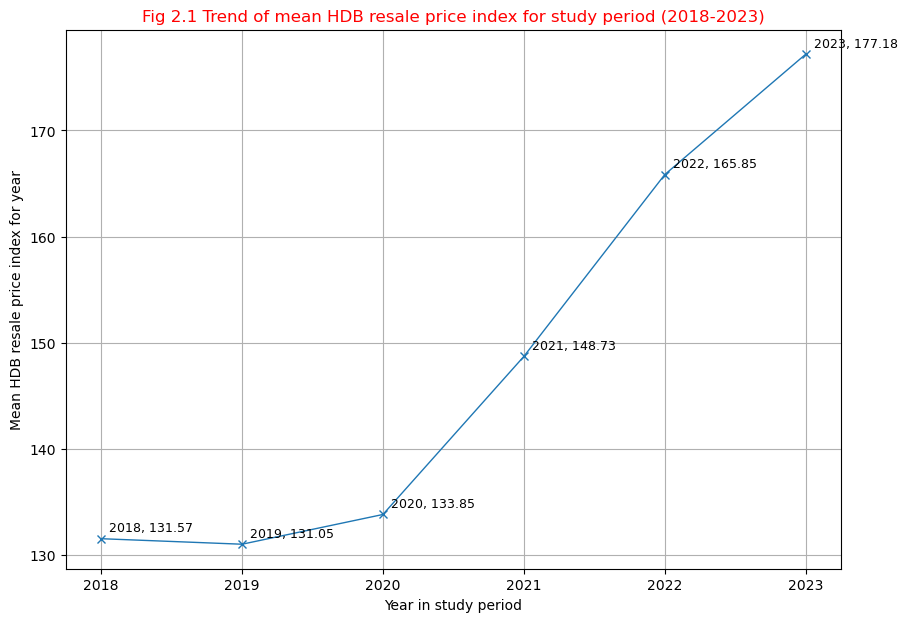

In [7]:
import matplotlib.pyplot as plt

x_data = [int(year_str) for year_str in dataset_fig_2_1['year'].tolist()]
y_data = dataset_fig_2_1['mean_index'].tolist()
# displaying the line connecting the data points will show the trend clearer
fig, axes = plt.subplots(figsize=(10, 7))
axes.plot(x_data, y_data, marker='x', markersize=6, linestyle='-', linewidth=1)

for x, y in zip(x_data, y_data):
    axes.annotate(f'{x}, {y:.2f}', (x, y), textcoords='offset points', xytext=(6, 5), ha='left', fontsize=9)

axes.set(xlabel='Year in study period', ylabel='Mean HDB resale price index for year')
axes.set_title("Fig 2.1 Trend of mean HDB resale price index for study period (2018-2023)", color="red")
axes.grid()
plt.savefig(figure_files["fig_2_1"], dpi=300, bbox_inches='tight')
plt.show()

**Section 2.2**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2018-2023 and representative estates

[3] Array mathematics
- Perform mean of resale price for whole year

[4] Transformation to new dataset
- Generate new row of mean statistics with year, estate, and append to new dataset array

[5] New dataset extraction operations
- Extract into correct x-axis and y-axis data format to input to matplotlib plot, minor data manipulations might be done

[6] Data presentation 
- Perform various plot adjustments to present statistics according to suitable display partitioning to answer section objective

In [8]:
import numpy as np

def extract_year_rows(year, data):
    print(f'Extracting rows for year: {year}')
    mask_y = np.char.startswith(data['quarter'], year)
    data_of_year = data[mask_y]
    return data_of_year

def extract_type_rows(type, data):
    print(f'Extracting rows for type: {type}')
    mask_t = (np.char.lower(data['flat_type']) == type.lower())
    data_of_type = data[mask_t]
    return data_of_type

def extract_estate_rows(estate, data):
    print(f'Extracting rows for estate: {estate}')
    mask_e = (np.char.lower(data['town']) == estate.lower())
    data_of_estate = data[mask_e]
    return data_of_estate

def init_mean_row_ds22():
    new_dtype = [('year','U10'), ('town','U30'), ('mean_price','i8')]
    empty_frame = np.empty((0,), dtype=new_dtype)
    return empty_frame

def generate_mean_row_ds22(year, town, price_mean):
    print(f'Generate mean row for year: {year}')
    new_dtype = [('year','U10'), ('town','U30'), ('mean_price','i8')]
    data_averaged = np.empty((1,), dtype=new_dtype)
    data_averaged['year'] = year
    data_averaged['town'] = town
    data_averaged['mean_price'] = price_mean
    return data_averaged

data = ndarr_final = data_of_year = None
debug_on = True

filename = dataset_files["data_set_2_2"]
print(f"Extracting data set 2_2 from file: {filename}")
dtype_ds_2_2=[('quarter','U10'), ('town','U30'), ('flat_type','U15'), ('price','i8')]

data = np.genfromtxt(filename, skip_header=1, dtype=dtype_ds_2_2 , delimiter=",", missing_values=['na','-'], filling_values=0)
print(f"Checking data set shape: {data.shape}")
print("Peeking at dataset first and last 5 rows:")
print(data[:5])
print(data[-5:])

ndarr_final = init_mean_row_ds22();

year_list = ['2018', '2019', '2020', '2021', '2022', '2023']
estate_list = ['Jurong East', 'Ang Mo Kio', 'Tampines', 'Woodlands']
flat_type = '4-room'
# filtering by year, estate, flat type, calculating mean and constructing new dataset for plot of fig 2.2
for year in year_list:
    print(f"----- {year} -----")
    data_of_year = extract_year_rows(year, data)
    #if(debug_on): print(data_of_year)

    for estate in estate_list:
        print(f"----- {estate} -----")
        data_of_estate = extract_estate_rows(estate, data_of_year)
        #if(debug_on): print(data_of_estate)
        data_of_flat_type = extract_type_rows(flat_type, data_of_estate)
        if(debug_on): print(data_of_flat_type)
        price_mean = np.mean(data_of_flat_type['price'])
        price_mean = round(price_mean)
        mean_row = generate_mean_row_ds22(year, estate, price_mean)
        if(debug_on): print(mean_row)
        ndarr_final = np.append(ndarr_final, mean_row)
        #if(debug_on): print(ndarr_final)

dataset_fig_2_2 = ndarr_final
print("-----")
print("Final dataset generated to use for fig 2.2:")
print(dataset_fig_2_2)

Extracting data set 2_2 from file: data/2/MedianResalePricesforRegisteredApplicationsbyTownandFlatType.csv
Checking data set shape: (11388,)
Peeking at dataset first and last 5 rows:
[('2007-Q2', 'Ang Mo Kio', '1-room',      0)
 ('2007-Q2', 'Ang Mo Kio', '2-room',      0)
 ('2007-Q2', 'Ang Mo Kio', '3-room', 172000)
 ('2007-Q2', 'Ang Mo Kio', '4-room', 260000)
 ('2007-Q2', 'Ang Mo Kio', '5-room', 372000)]
[('2025-Q2', 'YISHUN', '2-room', 352000)
 ('2025-Q2', 'YISHUN', '3-room', 438000)
 ('2025-Q2', 'YISHUN', '4-room', 569000)
 ('2025-Q2', 'YISHUN', '5-room', 716400)
 ('2025-Q2', 'YISHUN', 'Executive',      0)]
----- 2018 -----
Extracting rows for year: 2018
----- Jurong East -----
Extracting rows for estate: Jurong East
Extracting rows for type: 4-room
[('2018-Q1', 'Jurong East', '4-room', 417500)
 ('2018-Q2', 'Jurong East', '4-room', 407500)
 ('2018-Q3', 'Jurong East', '4-room', 429000)
 ('2018-Q4', 'Jurong East', '4-room', 390000)]
Generate mean row for year: 2018
[('2018', 'Jurong E

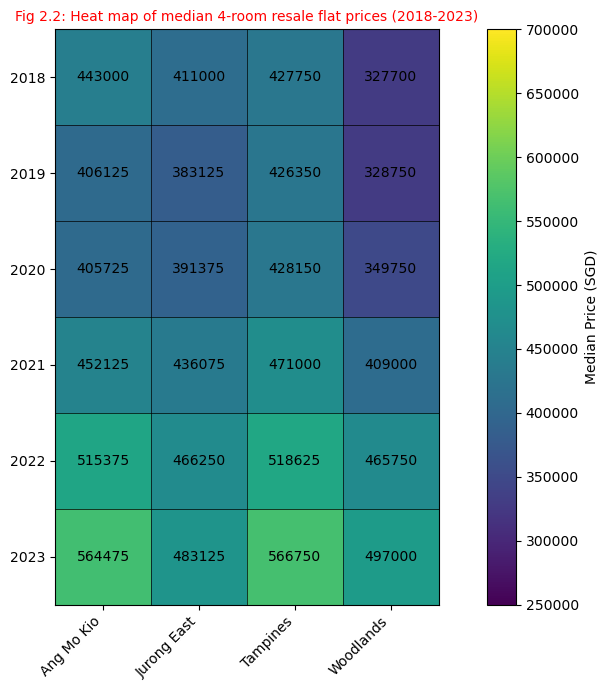

In [9]:
import matplotlib.pyplot as plt
import numpy as np

debug_on = False

years_ls = ['2018', '2019', '2020', '2021', '2022', '2023']
estate_ls = np.unique(dataset_fig_2_2['town']).tolist()
period_data_ls = []

if(debug_on): print(estate_ls)
# generating the plot data in correct format from dataset_fig_2_2
for year in years_ls:
    mask_year = (dataset_fig_2_2['year'] == year)
    year_subset = dataset_fig_2_2[mask_year]
    year_data_ls = []

    for estate in estate_ls:
        mask_estate = (year_subset['town'] == estate)
        estate_value = year_subset[mask_estate]['mean_price'].item()
        if(debug_on): print(f'estate: {estate}, value: {estate_value}')
        year_data_ls.append(estate_value)

    if(debug_on): print(f'year: {year}, year_data_ls: {year_data_ls}')
    period_data_ls.append(year_data_ls)

if(debug_on): print(period_data_ls)

dataset_fig_2_2_plot = np.array(period_data_ls)

fig, axes = plt.subplots(figsize=(10, 7))
im = axes.imshow(dataset_fig_2_2_plot, cmap="viridis", vmin=250000, vmax=700000)

axes.set_xticks(range(len(estate_ls)), labels=estate_ls, rotation=45, ha="right")
axes.set_yticks(range(len(years_ls)), labels=years_ls)

axes.set_xticks(np.arange(-0.5, len(estate_ls), 1), minor=True)
axes.set_yticks(np.arange(-0.5, len(years_ls), 1), minor=True)

axes.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
axes.tick_params(which="minor", bottom=False, left=False)
# annotating the plot for each yearly estate price value
for i in range(len(years_ls)):
    for j in range(len(estate_ls)):
        text = axes.text(j, i, dataset_fig_2_2_plot[i, j], ha="center", va="center", color="black")

cbar = fig.colorbar(im, ax=axes)
cbar.set_label("Median Price (SGD)")

axes.set_title("Fig 2.2: Heat map of median 4-room resale flat prices (2018-2023)", fontsize=10, color="red")
fig.tight_layout()
plt.savefig(figure_files["fig_2_2"], dpi=300, bbox_inches='tight')
plt.show()

**Section 2.3**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file

[2] Filtering data 
- Extract rows in focussed year range 2018-2023 and representative estates

[3] Transformation to new dataset
- Generate new row of filtered data with year, estate, price and append to new dataset array
- Other irrelevant columns of data from raw dataset are dropped for statistical focusing

[4] New dataset extraction operations
- Extract into correct x-axis and y-axis data format to input to matplotlib plot, minor data manipulations might be done

[5] Data presentation 
- Perform various plot adjustments to present statistics according to suitable display partitioning to answer section objective

In [10]:
import numpy as np

def extract_year_rows_ds23(year, data):
    print(f'Extracting rows for year: {year}')
    mask_y = np.char.startswith(data['month'], year)
    data_of_year = data[mask_y]
    return data_of_year

def extract_estate_rows(estate, data):
    print(f'Extracting rows for estate: {estate}')
    mask_e = (np.char.lower(data['town']) == estate.lower())
    data_of_estate = data[mask_e]
    return data_of_estate

def extract_type_rows(type, data):
    print(f'Extracting rows for type: {type}')
    mask_t = (np.char.lower(data['flat_type']) == type.lower())
    data_of_type = data[mask_t]
    return data_of_type

def init_mean_row_ds23():
    new_dtype = [('year','U10'), ('town','U30'), ('resale_price','i8')]
    empty_frame = np.empty((0,), dtype=new_dtype)
    return empty_frame

def generate_full_year_ds23(year, filtered_data):
    print(f'Generate full year dataset for year: {year}')
    new_dtype = [('year','U10'), ('town','U30'), ('resale_price','i8')]
    data_full_year = np.empty(filtered_data.shape, dtype=new_dtype)
    data_full_year['year'] = np.full(filtered_data.shape, year)
    data_full_year['town'] = filtered_data['town']
    data_full_year['resale_price'] = filtered_data['resale_price']
    return data_full_year

data = ndarr_final = data_of_year = data_of_estate = data_of_flat_type = None
debug_on = True

filename = dataset_files["data_set_2_3"]
print(f"Extracting data set 2_3 from file: {filename}")
dtype_ds_2_3=[('month','U10'), ('town','U30'), ('flat_type','U20'), ('block','U7'), ('street_name','U30'), 
              ('storey_range','U10'), ('floor_area_sqm','f8'), ('flat_model','U30'), ('lease_commence_date','U5'), 
              ('remaining_lease','U20'), ('resale_price','i8')]
data = np.genfromtxt(filename, skip_header=1, dtype=dtype_ds_2_3 , delimiter=",", missing_values=['na','-'], filling_values=0)
print(f"Checking data set shape: {data.shape}")
print("Peeking at dataset first and last 5 rows:")
print(data[:5])
print(data[-5:])

ndarr_final = init_mean_row_ds23();

year_list = ['2018', '2019', '2020', '2021', '2022', '2023']
estate_list = ['Jurong East', 'Ang Mo Kio', 'Tampines', 'Woodlands']
flat_type = '4 ROOM'

period_dataset_ls = []
 # filtering by year, estate, flat type and constructing new dataset for plot of fig 2.3
for year in year_list:
    print(f"----- {year} -----")
    data_of_year = extract_year_rows_ds23(year, data)
    #if(debug_on): print(data_of_year)

    estate_ndarr_ls = []

    for estate in estate_list:
        print(f"----- {estate} -----")
        data_of_estate = extract_estate_rows(estate, data_of_year)
        #if(debug_on): print(data_of_estate)
        data_of_flat_type = extract_type_rows(flat_type, data_of_estate)
        #if(debug_on): print(data_of_flat_type)
        #if(debug_on): print(data_of_flat_type.shape)
        full_year_rows = generate_full_year_ds23(year, data_of_flat_type)
        #if(debug_on): print(full_year_rows)
        estate_ndarr_ls.append(full_year_rows)

    # append to period dataset list for the processed year for all estates
    period_dataset_ls.append(estate_ndarr_ls)

    if(debug_on):
        print(f"----- estate ndarray list -----")
        for i in range(len(estate_ndarr_ls)):
            print(f"Shape of estate ndarr {i}: {estate_ndarr_ls[i].shape}")
            print(f"Peek at first row: {estate_ndarr_ls[i][0]}")
        #print(estate_ndarr_ls[3])

# final assignment of dataset for figure 2.3 
dataset_fig_2_3 = period_dataset_ls
dataset_fig_2_3_years = year_list
dataset_fig_2_3_estate = estate_list

if(debug_on):
    print(f"----- period dataset list -----")
    for i in range(len(period_dataset_ls)):
        print(f"  -- year {year_list[i]} --")
        year_list_size = len(period_dataset_ls[i])
        print(f"Size of element at index {i}: {year_list_size}")
        for j in range(year_list_size):
            ndarray_check = period_dataset_ls[i][j]
            print(f"shape of estate ndarray at inner index {j} : {ndarray_check.shape}")

Extracting data set 2_3 from file: data/2/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv
Checking data set shape: (221202,)
Peeking at dataset first and last 5 rows:
[('2017-01', 'ANG MO KIO', '2 ROOM', '406', 'ANG MO KIO AVE 10', '10 TO 12', 44., 'Improved', '1979', '61 years 04 months', 232000)
 ('2017-01', 'ANG MO KIO', '3 ROOM', '108', 'ANG MO KIO AVE 4', '01 TO 03', 67., 'New Generation', '1978', '60 years 07 months', 250000)
 ('2017-01', 'ANG MO KIO', '3 ROOM', '602', 'ANG MO KIO AVE 5', '01 TO 03', 67., 'New Generation', '1980', '62 years 05 months', 262000)
 ('2017-01', 'ANG MO KIO', '3 ROOM', '465', 'ANG MO KIO AVE 10', '04 TO 06', 68., 'New Generation', '1980', '62 years 01 month', 265000)
 ('2017-01', 'ANG MO KIO', '3 ROOM', '601', 'ANG MO KIO AVE 5', '01 TO 03', 67., 'New Generation', '1980', '62 years 05 months', 265000)]
[('2025-09', 'YISHUN', 'EXECUTIVE', '877', 'YISHUN ST 81', '10 TO 12', 145., 'Maisonette', '1987', '61 years 03 months',  980000)
 ('2025-

Generating plot (0,0) for estate index: 0, Jurong East
Generating plot (0,1) for estate index: 1, Ang Mo Kio
Generating plot (1,0) for estate index: 2, Tampines
Generating plot (1,1) for estate index: 3, Woodlands


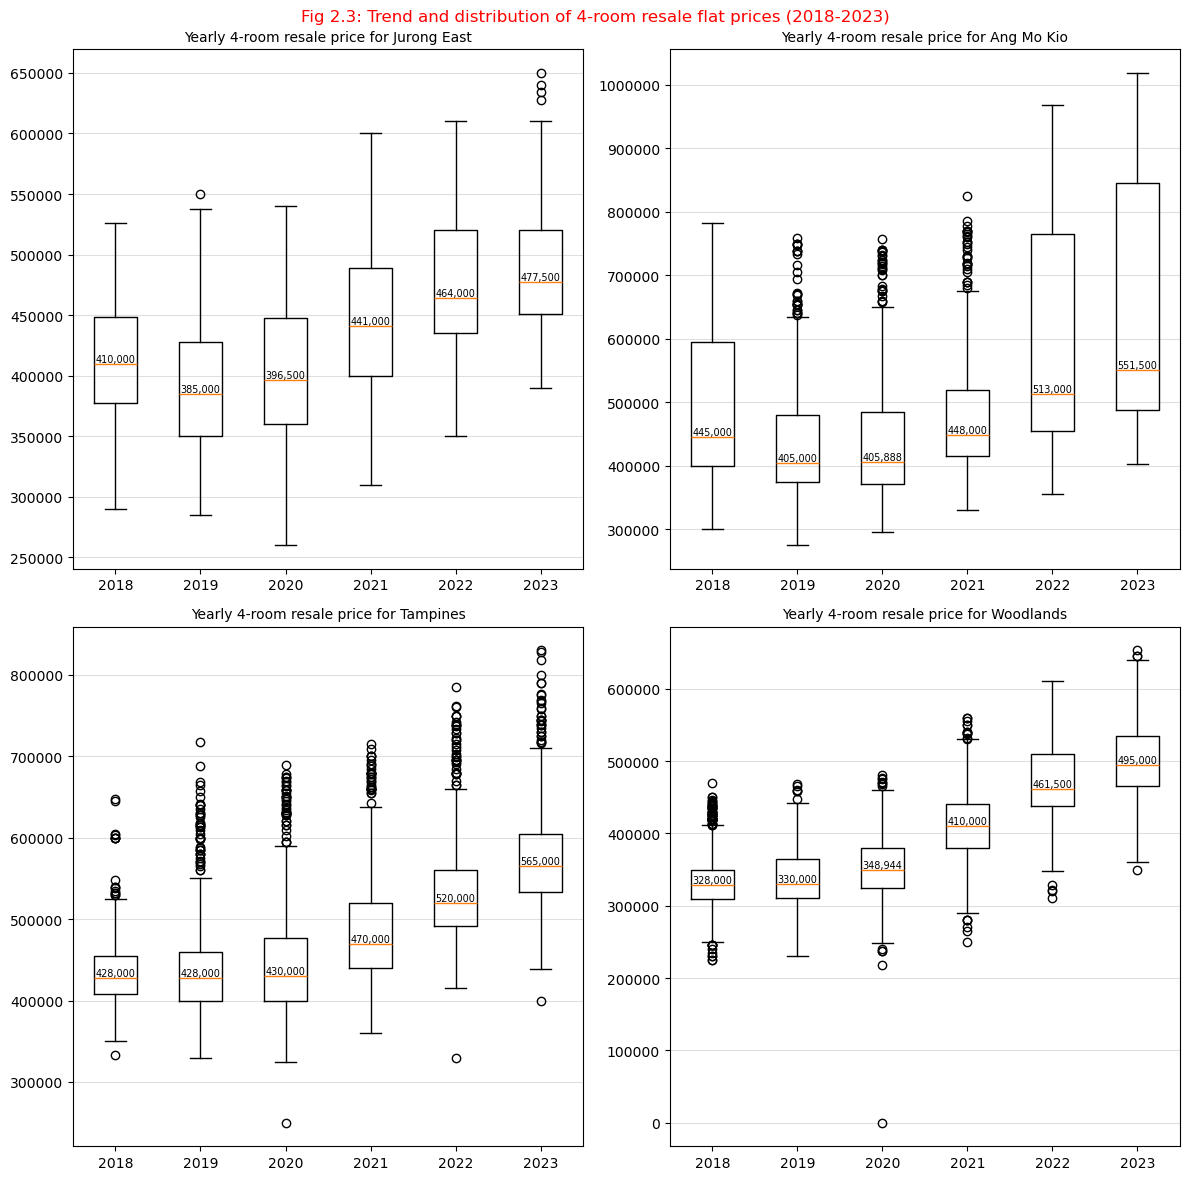

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# importing from previous cell: dataset_fig_2_3, dataset_fig_2_3_years, dataset_fig_2_3_estate 

def generate_plot_data_boxplot(dataset_fig, estate_index):
    plot_data_1_plot = []
    for i in range(len(dataset_fig)):
        year_ndarr = dataset_fig[i][estate_index]
        year_price_ndarr = year_ndarr['resale_price']
        plot_data_1_plot.append(year_price_ndarr)
        
    return plot_data_1_plot

debug_on = False 

if(debug_on):
    print(f"----- period dataset list -----")
    for i in range(len(dataset_fig_2_3)):
        print(f"  -- year {dataset_fig_2_3_years[i]} --")
        year_list_size = len(dataset_fig_2_3[i])
        print(f"Size of element at index {i}: {year_list_size}")
        for j in range(year_list_size):
            ndarray_check = dataset_fig_2_3[i][j]
            print(f"shape of estate: {dataset_fig_2_3_estate[j]} ndarray at inner index {j} : {ndarray_check.shape}")
            print(f"Peek at first row: {ndarray_check['resale_price'][0]}")

fs = 10
num_row = 2
num_col = 2
estate_index = 0

fig, axes = plt.subplots(nrows=num_row, ncols=num_col, figsize=(12, 12), sharey=False)

for i in range(num_row):
    for j in range(num_col):
        # extracting resale price data for each plot by estate
        plot_data_single = generate_plot_data_boxplot(dataset_fig_2_3, estate_index)
        plot_title = f"Yearly 4-room resale price for {dataset_fig_2_3_estate[estate_index]}"
        # Generating single boxplot for estate
        axes[i, j].boxplot(plot_data_single, tick_labels=dataset_fig_2_3_years)
        # overlay median values
        median_ls = [np.median(data) for data in plot_data_single]
        x_positions = np.arange(1, 1 + len(median_ls))
        for x, y in zip(x_positions, median_ls):
            axes[i, j].text(x, y, f'{int(y):,}', ha='center', va='bottom', fontsize=7, color='black', fontweight='normal', zorder=3)
        axes[i, j].set_title(plot_title, fontsize=fs)
        axes[i, j].grid(axis='y', alpha=0.4)
        print(f'Generating plot ({i},{j}) for estate index: {estate_index}, {dataset_fig_2_3_estate[estate_index]}')
        estate_index += 1

for ax in axes.flat:
    ax.set_yscale('linear')
    ax.ticklabel_format(style='plain', axis='y')

fig.subplots_adjust(hspace=0.4)
fig.suptitle("Fig 2.3: Trend and distribution of 4-room resale flat prices (2018-2023)", color="red")

plt.tight_layout()
plt.savefig(figure_files["fig_2_3"], dpi=300, bbox_inches='tight')
plt.show()

**Objective addressed for section 2**

From section 2.1, 2.2, 2.3, the plot results in line chart figure 2.1, heat map figure 2.2, box plots figure 2.3 show the same increasing resale price trend.
The line chart upward trend indicates that the national resale price index has been raising from before covid in 2018 to after covid from 2021 onwards. The heat map illustrating yearly resale prices in increasing color intensity scale also confirms that yearly resale prices of representative estates are following an increasing trend. Lastly, from the box plot showing a spectrum of resale prices for representative estates, it can be seen that the median resale prices are increasing from 2018 to 2023. Therefore, the claim in answer A1 that singapore resale prices has increased over recent years is correct as validated by the exploratory data analysis mentioned.

---------------------------
**Section 3**

Implement data retrival, manipulation, transformation, presentation operations to address objective 3) Investigate the relationship between resale prices and median rent for 4-room flat type mentioned in section 1)

**section 3.1) data_set_3_1**

data.gov.sg dataset: Median Rent By Town And Flat Type

URL: https://data.gov.sg/datasets?query=hdb&resultId=d_23000a00c52996c55106084ed0339566&page=6&dataExplorerPage=1284

filename: MedianRentByTownAndFlatType.csv

output result analysis plot filename: fig_3_1.jpg

output plot type: scatter plot

**Section 3.1**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2018-2023, 4-room type, representative estates

[3] Array mathematics
- Perform mean of rent for whole year

[4] Transformation to new dataset
- Generate new row of mean statistics with year, estate, flat type and append to new dataset array

[5] New dataset extraction operations
- Extract into correct x-axis and y-axis data format to input to matplotlib plot, minor data manipulations might be done

[6] Data presentation 
- Perform various plot adjustments to present statistics according to suitable display partitioning to answer section objective

In [12]:
import numpy as np

def extract_year_rows(year, data):
    print(f'Extracting rows for year: {year}')
    mask_y = np.char.startswith(data['quarter'], year)
    data_of_year = data[mask_y]
    return data_of_year

def extract_category_rows(category, value, data):
    print(f'Extracting rows for category: {category} with value: {value}')
    mask_cat = (np.char.lower(data[category]) == value.lower())
    data_of_category = data[mask_cat]
    return data_of_category

def init_ndarray_ds31(data):
    new_dtype = [('year','U10'), ('town','U30'), ('mean_price','i8'), ('mean_rent','i8')]
    new_ndarray = np.empty(data.shape, dtype=new_dtype)
    new_ndarray['year'] = data['year']
    new_ndarray['town'] = data['town']
    new_ndarray['mean_price'] = data['mean_price']
    new_ndarray['mean_rent'] = np.full(data.shape[0], 0)
    return new_ndarray

ndarr_final = data = data_of_year = data_of_estate = data_of_flat_type = None
debug_on = True

filename = dataset_files["data_set_3_1"]
print(f"Extracting data set 3_1 from file: {filename}")
dtype_ds_3_1=[('quarter','U10'), ('town','U30'), ('flat_type','U10'), ('median_rent','i8')]

data = np.genfromtxt(filename, skip_header=1, dtype=dtype_ds_3_1 , delimiter=",", missing_values=['na','-'], filling_values=0)
print(f"Checking data set shape: {data.shape}")
print("Peeking at dataset first and last 5 rows:")
print(data[:5])
print(data[-5:])

year_list = ['2018', '2019', '2020', '2021', '2022', '2023']
#estate_list = ['jurong east', 'ang mo kio', 'tampines', 'woodlands']
estate_list = np.unique(dataset_fig_2_2['town']).tolist()
#if(debug_on): print(f"Check estate list: {estate_list}")

flat_type = '4-RM'
col_header_estate = 'town'
col_header_type = 'flat_type'

ndarr_final = init_ndarray_ds31(dataset_fig_2_2)

# filtering by year and estate, calculating mean and constructing new dataset for plot of fig 3.1
for year in year_list:
    print(f"----- {year} -----")
    data_of_year = extract_year_rows(year, data)
    #if(debug_on): print(data_of_year)

    estate_ndarr_ls = []
    for estate in estate_list:
        print(f"----- {estate} -----")
        data_of_estate = extract_category_rows(col_header_estate, estate, data_of_year)
        #if(debug_on): print(data_of_estate)
        data_of_flat_type = extract_category_rows(col_header_type, flat_type, data_of_estate)
        rent_mean = np.mean(data_of_flat_type['median_rent'])
        rent_mean = round(rent_mean)
        if(debug_on): 
            print(data_of_flat_type)
            print(f"mean_rent: {rent_mean}")
        # Search for row matching year and estate, insert value to mean_rent column
        search_index_ls = np.where((ndarr_final['year'] == year) & (ndarr_final['town'] == estate))[0]
        if search_index_ls.size == 1:
            #if(debug_on): print(f"Found search index for {year}, {estate} : {search_index_ls}")
            search_index = search_index_ls[0]
            ndarr_final['mean_rent'][search_index] = rent_mean

dataset_fig_3_1 = ndarr_final
print(dataset_fig_3_1)  
print(dataset_fig_3_1.dtype.names)

Extracting data set 3_1 from file: data/3/MedianRentByTownAndFlatType.csv
Checking data set shape: (12837,)
Peeking at dataset first and last 5 rows:
[('2005-Q2', 'ANG MO KIO', '1-RM',   0)
 ('2005-Q2', 'ANG MO KIO', '2-RM',   0)
 ('2005-Q2', 'ANG MO KIO', '3-RM', 800)
 ('2005-Q2', 'ANG MO KIO', '4-RM', 950)
 ('2005-Q2', 'ANG MO KIO', '5-RM',   0)]
[('2025-Q3', 'YISHUN', '2-RM',    0) ('2025-Q3', 'YISHUN', '3-RM', 2630)
 ('2025-Q3', 'YISHUN', '4-RM', 3100) ('2025-Q3', 'YISHUN', '5-RM', 3400)
 ('2025-Q3', 'YISHUN', 'EXEC',    0)]
----- 2018 -----
Extracting rows for year: 2018
----- Ang Mo Kio -----
Extracting rows for category: town with value: Ang Mo Kio
Extracting rows for category: flat_type with value: 4-RM
[('2018-Q1', 'ANG MO KIO', '4-RM', 2100)
 ('2018-Q2', 'ANG MO KIO', '4-RM', 2000)
 ('2018-Q3', 'ANG MO KIO', '4-RM', 2100)
 ('2018-Q4', 'ANG MO KIO', '4-RM', 2100)]
mean_rent: 2075
----- Jurong East -----
Extracting rows for category: town with value: Jurong East
Extracting rows

---- Ang Mo Kio ----
[('2018', 'Ang Mo Kio', 443000, 2075) ('2019', 'Ang Mo Kio', 406125, 2100)
 ('2020', 'Ang Mo Kio', 405725, 2108) ('2021', 'Ang Mo Kio', 452125, 2225)
 ('2022', 'Ang Mo Kio', 515375, 2562) ('2023', 'Ang Mo Kio', 564475, 3295)]
---- Jurong East ----
[('2018', 'Jurong East', 411000, 2025)
 ('2019', 'Jurong East', 383125, 2043)
 ('2020', 'Jurong East', 391375, 2040)
 ('2021', 'Jurong East', 436075, 2162)
 ('2022', 'Jurong East', 466250, 2588)
 ('2023', 'Jurong East', 483125, 3200)]
---- Tampines ----
[('2018', 'Tampines', 427750, 2000) ('2019', 'Tampines', 426350, 2000)
 ('2020', 'Tampines', 428150, 2060) ('2021', 'Tampines', 471000, 2150)
 ('2022', 'Tampines', 518625, 2488) ('2023', 'Tampines', 566750, 3212)]
---- Woodlands ----
[('2018', 'Woodlands', 327700, 1732) ('2019', 'Woodlands', 328750, 1717)
 ('2020', 'Woodlands', 349750, 1774) ('2021', 'Woodlands', 409000, 1900)
 ('2022', 'Woodlands', 465750, 2388) ('2023', 'Woodlands', 497000, 3000)]


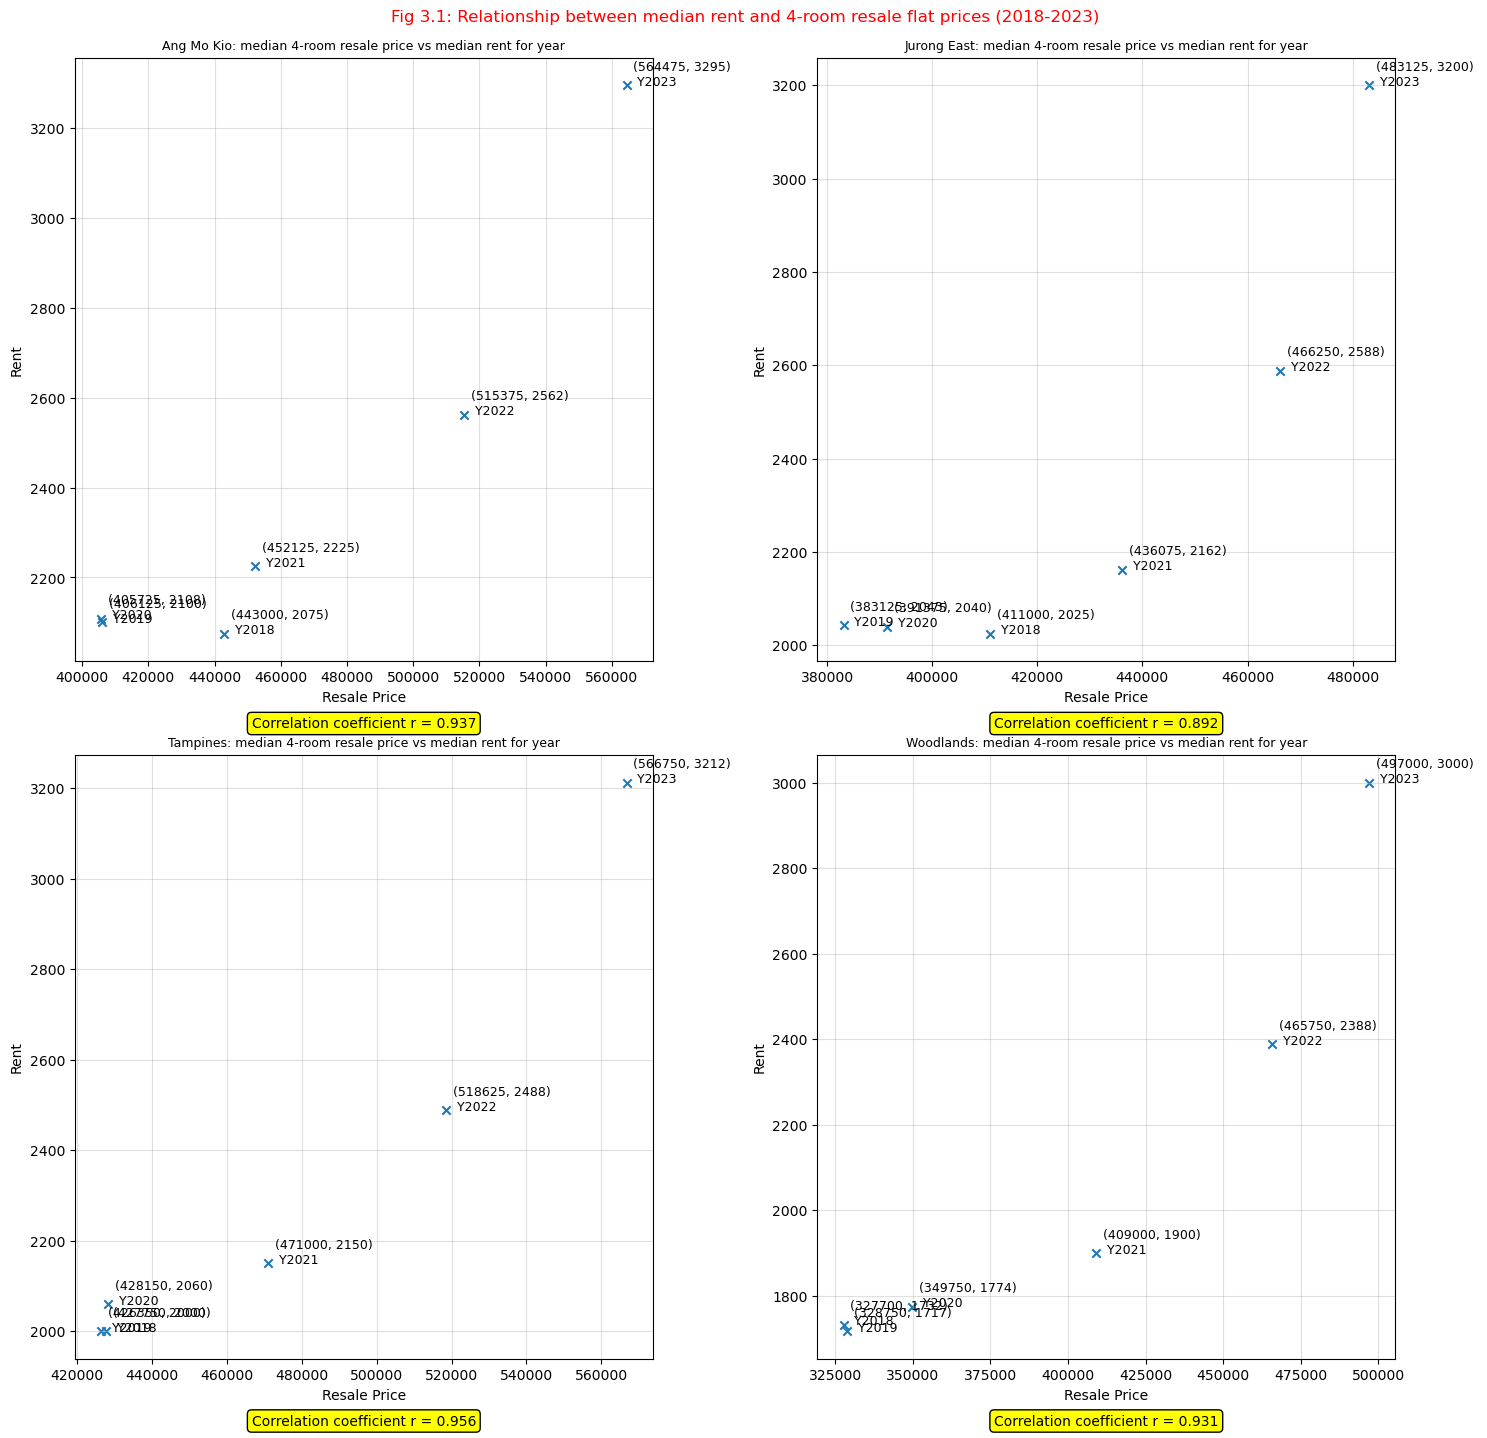

In [13]:
import matplotlib.pyplot as plt
import numpy as np

debug_on = True 

def filter_estate_rows(dataset_fig, estate):
    mask_e = dataset_fig['town'] == estate
    data = dataset_fig[mask_e]
    return data

def annotate_plot(axes_i, x, y, z):
    for x_val, y_val, z_val in zip(x, y, z):
        axes_i.annotate(f"({x_val}, {y_val}) \n Y{z_val}", 
            (x_val, y_val),
            textcoords="offset points",
            xytext=(5, 0),
            ha="left",
            fontsize=9
        )
    # calculate pearson coefficient and annotate
    r = np.corrcoef(x, y)[0, 1]
    axes_i.text(
        0.5, -0.11,
        f"Correlation coefficient r = {r:.3f}",
        transform=axes_i.transAxes,
        ha="center",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="yellow")
    )    

num_row = 2
num_col = 2
estate_index = 0

estate_list = np.unique(dataset_fig_3_1['town']).tolist()

fig, axes = plt.subplots(nrows=num_row, ncols=num_col, figsize=(15, 15))
for i in range(num_row):
    for j in range(num_col):
        estate_name = estate_list[estate_index]
        print(f"---- {estate_name} ----")
        # filtering and plotting by each estate for scatter plot
        data_estate = filter_estate_rows(dataset_fig_3_1, estate_name)
        if debug_on: print(data_estate)

        x = data_estate['mean_price']
        y = data_estate['mean_rent']
        z = data_estate['year']
        axes[i,j].scatter(x, y, marker='x')
        annotate_plot(axes[i,j], x, y, z)
        axes[i,j].set_title(f"{estate_name}: median 4-room resale price vs median rent for year", fontsize=9)
        axes[i,j].grid(alpha=0.4)
        estate_index += 1

for axes_i in axes.flat:
    axes_i.set_xlabel("Resale Price", fontsize=10)
    axes_i.set_ylabel("Rent", fontsize=10)
    axes_i.tick_params(axis='both', labelsize=10)

fig.suptitle("Fig 3.1: Relationship between median rent and 4-room resale flat prices (2018-2023)", color="red")
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.savefig(figure_files["fig_3_1"], dpi=300, bbox_inches='tight') 
plt.show()

**Objective addressed for section 3**

From section 3.1, the plot results in scatter plots of figure 3.1 show the same linear relationship between exploratory variable resale price and reactionary variable rent for all four estates (woodlands, jurong east, tampines, ang mo kio). All calculated pearson coefficients values indicate positive, strong linear relationship between resale price and rent. With +1 reflecting perfect positive correlation, 0 reflecting no linear correlation, -1 reflecting perfect negative correlation linear relationship.
Therefore, the claim in answer A2 that HDB resale prices has significantly contributed to rising rental costs seems to be true as per pearson coefficient computed and scatter plot result suggested.

---------------------------
**Section 4**

Implement data retrival, manipulation, transformation, presentation operations to address objective 4) Investigate if the claimed causes of resale price increase situation is correct.

**section 4.1) data_set_4_1**

data.gov.sg dataset: Completion Status of HDB Residential Developments

URL: https://data.gov.sg/datasets?query=hdb&resultId=d_582672d2f972194786d01efe151892b7

filename: CompletionStatusofHDBResidentialDevelopments.csv

output result analysis plot filename: fig_4_1.jpg

output plot type: stacked bar chart

**section 4.2) data_set_4_2**

data.gov.sg dataset: CPF Housing Grants Awarded by Type

URL: https://data.gov.sg/datasets?query=hdb&resultId=d_a223380e5856cf06f7eac223e5902230&page=6&dataExplorerPage=9

filename: CPFHousingGrantsAwardedbyType.csv

output result analysis plot filename: fig_4_2.jpg

output plot type: stackplot

**Section 4.1**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2018-2023, housing type and status

[3] Transformation to new dataset
- Generate new filtered row with year, type, status, number of units and append to new dataset array

[4] New dataset extraction operations
- Extract into correct x-axis and y-axis data format to input to matplotlib plot, minor data manipulations might be done

[5] Data presentation 
- Perform various plot adjustments to present statistics according to suitable display partitioning to answer section objective

In [14]:
import numpy as np

def extract_category_rows(category, value, data):
    print(f'Extracting rows for category: {category} with value: {value}')
    mask_cat = (np.char.lower(data[category]) == value.lower())
    data_of_category = data[mask_cat]
    return data_of_category

def init_mean_row_ds41():
    new_dtype = [('financial_year','U10'), ('type','U15'), ('status','U25'), ('no_of_units','i8')]
    empty_frame = np.empty((0,), dtype=new_dtype)
    return empty_frame

ndarr_final = data = data_of_year = data_of_selection = None
debug_on = False

filename = dataset_files["data_set_4_1"]
print(f"Extracting data set 4_1 from file: {filename}")
dtype_ds_4_1=[('financial_year','U10'), ('type','U15'), ('status','U25'), ('no_of_units','i8')]

data = np.genfromtxt(filename, skip_header=1, dtype=dtype_ds_4_1 , delimiter=",", missing_values=['na','-'], filling_values=0)
print(f"Checking data set shape: {data.shape}")
print("Peeking at dataset first and last 4 rows:")
print(data[:4])
print(data[-4:])

ndarr_final = init_mean_row_ds41();

year_list = ['2018', '2019', '2020', '2021', '2022', '2023']
col_year_header = 'financial_year'

selection_type = 'HDB Flats'
selection_status = ['Completed', 'Under Construction']

for year in year_list:
    print(f"----- {year} -----")
    data_of_year = extract_category_rows(col_year_header, year, data)
    #if(debug_on): print(data_of_year)
    # selecting rows that are type = 'HDB Flats' and status = 'Completed' || 'Under Construction'
    mask_selection = ( (data_of_year['type'] == selection_type) & np.isin(data_of_year['status'], selection_status) )
    data_of_selection = data_of_year[mask_selection]
    if(debug_on): print(data_of_selection)
    ndarr_final = np.append(ndarr_final, data_of_selection)

dataset_fig_4_1 = ndarr_final
print(f"----------")
print("Checking dataset_fig_4_1:")
print(dataset_fig_4_1)

Extracting data set 4_1 from file: data/4/CompletionStatusofHDBResidentialDevelopments.csv
Checking data set shape: (85,)
Peeking at dataset first and last 4 rows:
[('2007', 'HDB Flats', 'Completed',  6247)
 ('2007', 'HDB Flats', 'Under Construction', 18073)
 ('2007', 'HDB Flats', 'Awarded', 10108)
 ('2007', 'DBSS', 'Completed',     0)]
[('2023', 'HDB Flats', 'Under Construction', 82320)
 ('2023', 'HDB Flats', 'Awarded', 24287)
 ('2023', 'DBSS', 'Completed',     0)
 ('2023', 'DBSS', 'Under Construction',     0)]
----- 2018 -----
Extracting rows for category: financial_year with value: 2018
----- 2019 -----
Extracting rows for category: financial_year with value: 2019
----- 2020 -----
Extracting rows for category: financial_year with value: 2020
----- 2021 -----
Extracting rows for category: financial_year with value: 2021
----- 2022 -----
Extracting rows for category: financial_year with value: 2022
----- 2023 -----
Extracting rows for category: financial_year with value: 2023
--------

Extracting rows for category: status with value: Completed
Extracting rows for category: status with value: Under Construction


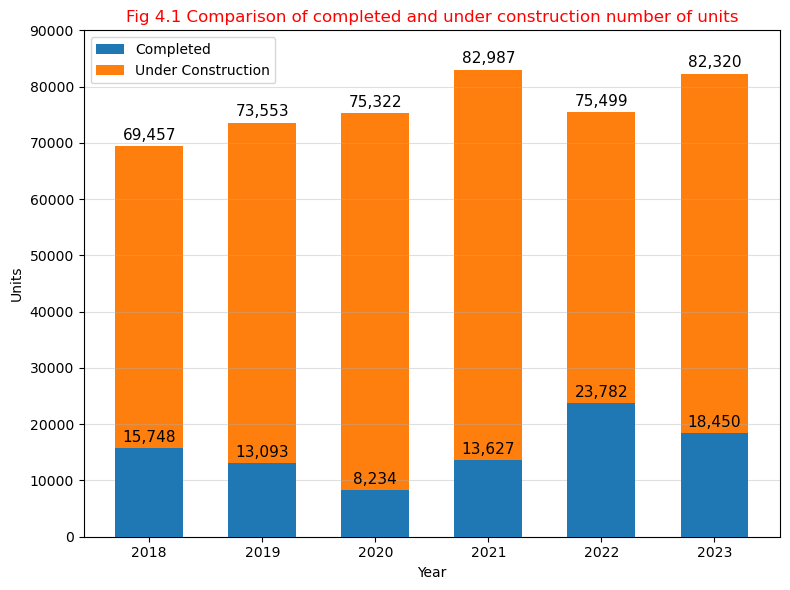

In [15]:
import matplotlib.pyplot as plt
import numpy as np

debug_on = False 

def extract_category_rows(category, value, data):
    print(f'Extracting rows for category: {category} with value: {value}')
    mask_cat = (np.char.lower(data[category]) == value.lower())
    data_of_category = data[mask_cat]
    return data_of_category

def annotate_bars(axes, x, values, offset):
    fmt="{:,.0f}"
    for x_i, y_value in zip(x, values):
        axes.text(x_i, y_value + offset, fmt.format(y_value), ha="center", va="bottom", fontsize=11)

if debug_on: 
    print('Checking raw dataset for fig 4.1:')
    print(dataset_fig_4_1)

ndarr_x_axis = ndarr_y_axis = data_for_category = None

col_header_status ='status'
col_header_year ='financial_year'
col_header_units = 'no_of_units'
filter_value_ls = ['Completed', 'Under Construction']

bar_width = 0.6
bar_z_order = [100, 1]

fig, axes = plt.subplots(figsize=(8, 6))

for i in range(len(filter_value_ls)):
    # data preparation for input to stacked bar chart
    data_for_category = extract_category_rows(col_header_status, filter_value_ls[i], dataset_fig_4_1)
    ndarr_y_axis = data_for_category[col_header_units]
    ndarr_x_axis = data_for_category[col_header_year]
    x_axis_pos = np.arange(ndarr_x_axis.size)
    # adding z order will allow display of 1st bar chart to be front of 2nd bar chart 
    axes.bar(x_axis_pos, ndarr_y_axis, bar_width, label=filter_value_ls[i], zorder=bar_z_order[i])
    annotate_bars(axes, x_axis_pos, ndarr_y_axis.tolist(), offset=600)

    if debug_on:
        print(f"---- {filter_value_ls[i]} ----")
        print(ndarr_y_axis)
        print(ndarr_x_axis)

axes.set_ylim(ymax=90000)
axes.set_xticks(x_axis_pos)
axes.set_xticklabels(ndarr_x_axis.tolist())
axes.set_xlabel("Year")
axes.set_ylabel("Units")
axes.set_title("Fig 4.1 Comparison of completed and under construction number of units", color="red")
axes.legend()
axes.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(figure_files["fig_4_1"], dpi=300, bbox_inches='tight')
plt.show()

**Section 4.2**

Implemented steps

[1] Data retrival                   
- Read from data.gov raw dataset file 

[2] Filtering data 
- Extract rows in focussed year range 2018-2023

[3] Array mathematics
- Perform sum of households for whole year for each housing grant scheme

[4] Transformation to new dataset
- Generate new row of summed statistics with year, scheme and append to new dataset array

[5] New dataset extraction operations
- Extract into correct x-axis and y-axis data format to input to matplotlib plot, minor data manipulations might be done

[6] Data presentation 
- Perform various plot adjustments to present statistics according to suitable display partitioning to answer section objective

In [16]:
import numpy as np
from pprint import pprint

def extract_category_rows(category, value, data):
    print(f'Extracting rows for category: {category} with value: {value}')
    mask_cat = (np.char.lower(data[category]) == value.lower())
    data_of_category = data[mask_cat]
    return data_of_category

def generate_sum_row_ds42(year, grant_scheme, hh_sum):
    new_dtype = [('financial_year','U10'), ('housing_grant_scheme','U40'), ('no_of_hh','i8')]
    data_sum = np.empty((1,), dtype=new_dtype)
    data_sum['financial_year'] = year
    data_sum['housing_grant_scheme'] = grant_scheme
    data_sum['no_of_hh'] = hh_sum
    return data_sum

def init_mean_row_ds42():
    new_dtype = [('financial_year','U10'), ('housing_grant_scheme','U40'), ('no_of_hh','i8')]
    empty_frame = np.empty((0,), dtype=new_dtype)
    return empty_frame

ndarr_final = data = data_of_year = data_of_scheme = grant_scheme_ls = None
debug_on = True

filename = dataset_files["data_set_4_2"]
print(f"Extracting data set 4_2 from file: {filename}")
dtype_ds_4_2=[('financial_year','U10'), ('housing_grant_scheme','U40'), ('type_of_grant','U60'), ('no_of_hh','i8')]

data = np.genfromtxt(filename, skip_header=1, dtype=dtype_ds_4_2 , delimiter=",", missing_values=['na','-'], filling_values=0)
print(f"Checking data set shape: {data.shape}")
print("Peeking at dataset first and last 4 rows:")
print(data[:4])
print(data[-4:])

ndarr_final = init_mean_row_ds42()

year_list = ['2018', '2019', '2020', '2021', '2022', '2023']
col_year_header = 'financial_year'
col_grant_scheme_header = 'housing_grant_scheme'

for year in year_list:
    print(f"----- {year} -----")
    data_of_year = extract_category_rows(col_year_header, year, data)
    #if debug_on: print(data_of_year)
    grant_scheme_ls = np.unique(data_of_year['housing_grant_scheme']).tolist()
    #if debug_on: print(grant_scheme_ls)
    for grant_type in grant_scheme_ls:
        data_of_scheme = extract_category_rows(col_grant_scheme_header, grant_type, data_of_year)
        if debug_on: print(f"----- {grant_type} -----")
        #if debug_on: print(data_of_scheme)
        hh_sum = np.sum(data_of_scheme['no_of_hh'])
        #if debug_on: print(f"household sum: {hh_sum}")
        sum_row = generate_sum_row_ds42(year, grant_type, hh_sum)
        #if debug_on: print(sum_row)
        ndarr_final = np.append(ndarr_final, sum_row)

print("-----")
if debug_on: 
    print("Checking ndarr_final: ")
    print(ndarr_final)
data_of_scheme = None
grant_scheme_ls = np.unique(ndarr_final['housing_grant_scheme']).tolist()

grant_hh_by_year_ls = []

for grant_type in grant_scheme_ls:
    grant_hh_ls = []
    for year in year_list:
        num_of_hh = 0
        search_index_ls = np.where((ndarr_final['financial_year'] == year) & (ndarr_final['housing_grant_scheme'] == grant_type))[0]

        if search_index_ls.size == 1:
            #if(debug_on): print(f"Found search index for {year}, {grant_type} : {search_index_ls}")
            search_index = search_index_ls[0]
            num_of_hh = ndarr_final['no_of_hh'][search_index].item()
        
        grant_hh_ls.append(num_of_hh)
    # after looping each year and searching for grant type, append grant_hh_ls to dataset_hh_ls
    grant_hh_by_year_ls.append(grant_hh_ls)

print("-----")
#if(debug_on): print(grant_scheme_ls)
#if(debug_on): print(grant_hh_by_year_ls)

dataset_fig_4_2 = { "years": [int(year_str) for year_str in year_list], "grant_scheme": grant_scheme_ls, "households": grant_hh_by_year_ls }
if debug_on: 
    print("Checking dataset_fig_4_2: ")
    pprint(dataset_fig_4_2)

Extracting data set 4_2 from file: data/4/CPFHousingGrantsAwardedbyType.csv
Checking data set shape: (102,)
Peeking at dataset first and last 4 rows:
[('2010', 'CPF Housing Grant', 'Family Grant (living near parents/married child)', 2249)
 ('2010', 'CPF Housing Grant', 'Family Grant', 4198)
 ('2010', 'CPF Housing Grant', 'Singles Grant',  926)
 ('2010', 'CPF Housing Grant', 'Joint Singles Grant',   59)]
[('2023', 'CPF Housing Grant', 'Singles Grant (living with parents)',     0)
 ('2023', 'CPF Housing Grant', 'Joint Singles Grant',    54)
 ('2023', 'Additional CPF Housing Grant', 'na', 14038)
 ('2023', 'Proximity Housing Grant', 'na', 10487)]
----- 2018 -----
Extracting rows for category: financial_year with value: 2018
Extracting rows for category: housing_grant_scheme with value: Additional CPF Housing Grant
----- Additional CPF Housing Grant -----
Extracting rows for category: housing_grant_scheme with value: CPF Housing Grant
----- CPF Housing Grant -----
Extracting rows for catego

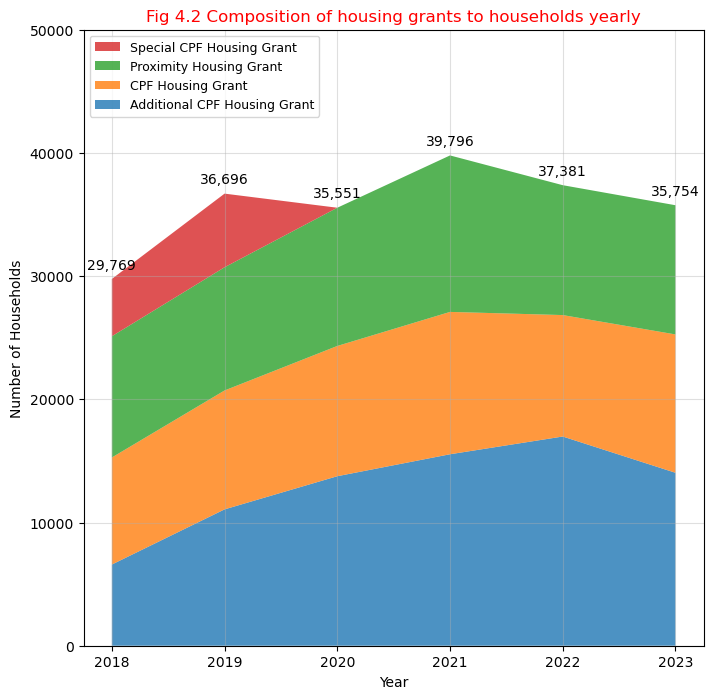

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint

debug_on = False 

grant_scheme_ls = year_ls = hh_by_grant_type = None

year_ls = dataset_fig_4_2["years"]
grant_scheme_ls = dataset_fig_4_2["grant_scheme"]

hh_by_grant_type = dict.fromkeys(grant_scheme_ls, [])
# assembling hh_by_grant_type dictionary for input to stackplot
for i in range(len(grant_scheme_ls)):
    key_name = grant_scheme_ls[i]
    hh_by_grant_type[key_name] = dataset_fig_4_2["households"][i]
# calculating the total sum of households for each year for annotation purposes
hh_ndarr = np.array(list(hh_by_grant_type.values()))
total_hh_ls= (hh_ndarr.sum(axis=0)).tolist()

if debug_on: 
    pprint(hh_by_grant_type)
    print(total_hh_ls)

fig, axes = plt.subplots(figsize=(8, 8))
axes.stackplot(year_ls, hh_by_grant_type.values(), labels=hh_by_grant_type.keys(), alpha=0.8)

axes.set_ylim(ymax=50000)
axes.legend(loc='upper left', reverse=True, fontsize=9)
axes.set_xlabel('Year')
axes.set_ylabel('Number of Households')
axes.set_title('Fig 4.2 Composition of housing grants to households yearly', color="red")
axes.grid(alpha=0.4)
# annotate peak of year chart with total sum of households
for x_val, y_val in zip(year_ls, total_hh_ls):
    axes.annotate(f'{y_val:,}', xy=(x_val, y_val), xytext=(0, 5), 
                  textcoords='offset points', ha='center', va='bottom', fontsize=10)

plt.savefig(figure_files["fig_4_2"], dpi=300, bbox_inches='tight')
plt.show()

**Objective addressed for section 4**

From section 4.1, 4.2, the plot results in stacked bar chart figure 4.1, stacked plot figure 4.2, the causes for the resale price increase are validated through two areas of completed status of HDB residential developments and CPF housing grants awarded. The stacked bar chart plot results indicate that the gap between completed and under construction units had widen from 2018 to 2021, but the gap managed to decrease in 2022, before widening again in 2023. This comparison highlights the construction situation where housing demand is increasing steadily over recent years while new housing supply was constrained by covid and could take time to recover and catch up.
The stacked plot chart indicates that CPF housing grants awarded to households has increased to peak in 2021, and then there was a drop from 2021 to 2023. This composition and upward trend highlights that increased housing grants made available to more households could likely increase their purchasing power to purchase resale flats, adding onto the increased demand for resale flats, which in turn causes the resale market prices to surge. 
Therefore, the claim in answer A1 regarding the potential causes for the HDB resale price increase seems to be true as per exploratory data analysis performed and deductions obtained from both plot results mentioned above. 

**End of workbook**

---------------------------